In the previous notebook we created a recursive SQL query that can construct a
CAD for a given set of constraints in arbitrary dimensions. We will now test a
similar approach, but with fixed columns instead of storing each dimension's
value in a row.

In this notebook, we will:

1. Create a hardcoded approach for 4 dimensions.
2. Move towards a generic approach where Python code generates a SQL query for
   $n$ dimensions.
3. Test this approach's performance

## Hardcoded query

We start again from our familiar formula from the previous notebook, where we
have some function with $k$ inputs and a number of constraints:

 $\exists x_1,\ldots ,x_k\ .\ (F(x_1, \ldots, x_k) > k) \land (x_1 < k) \land ... \land (x_k < k)$

For 3 inputs this becomes:

$\exists x,y,z\ .\ F(x,y,z) > 3 \land x < 3 \land y < 3 \land z < 3$

Now take $F(x,y,z)=max(0, x+y+z)$ as the function. We "compile" this to the LRA
formula:

$\exists x,y,z,u\ .\ x < 3 \land y < 3 \land z < 3 \land (x+y+z \leq 0
\rightarrow u=0) \land (x+y+z > 0 \implies u=x+y+z) \land u > 3$

Let's try to construct a CAD for this formula. The database schema becomes
simpler. We have a single table now, `LinearConstraint(id, description, a0, a1,
a2, a3, a4)`, where each coefficient is simply a column. Let's set up the
database and insert the constraints.

In [1]:
import duckdb as db
import copy

DBNAME = "dbs/cad_columns.db"

with db.connect(DBNAME) as con:
    con.sql("DROP TABLE IF EXISTS LinearConstraint")
    con.sql("""
        CREATE TABLE LinearConstraint(
            id INTEGER PRIMARY KEY,
            description VARCHAR NOT NULL,
            a0 DOUBLE DEFAULT 0.0,
            a1 DOUBLE DEFAULT 0.0,
            a2 DOUBLE DEFAULT 0.0,
            a3 DOUBLE DEFAULT 0.0,
            a4 DOUBLE DEFAULT 0.0
        )
    """)

    constraints = [
        ["x+y+z", 0, 1, 1, 1, 0],
        ["u", 0, 0, 0, 0, 1],
        ["x+y+z-u", 0, 1, 1, 1, -1],
        ["u-3", -3, 0, 0, 0, 1],
        ["x-3", -3, 1, 0, 0, 0],
        ["y-3", -3, 0, 1, 0, 0],
        ["z-3", -3, 0, 0, 1, 0]
    ]

    for id, constraint in enumerate(constraints, start=1):
        con.execute("""
                INSERT INTO LinearConstraint(id, description, a0, a1, a2, a3, a4)
                VALUES (?, ?, ?, ?, ?, ?, ?)
            """, [id] + constraint)

The full query can be found in
[queries/column-based/4dims.sql](./queries/column-based/4dims.sql).

The column-based approach makes the recursive CTEs in particular harder. In the
projection phase we project to one dimension lower in each step. This means that
we have to do some bookkeeping and perform the correct calculations for each
step. For example, when calculating the `a0` coefficient in the intersection
step, we need to know which dimension we are currently projecting away:

```sql
CASE
    WHEN a.dim_to_project = 4 THEN (a.a0 / a.a4) - (b.a0 / b.a4)
    WHEN a.dim_to_project = 3 THEN (a.a0 / a.a3) - (b.a0 / b.a3)
    WHEN a.dim_to_project = 2 THEN (a.a0 / a.a2) - (b.a0 / b.a2)
    WHEN a.dim_to_project = 1 THEN (a.a0 / a.a1) - (b.a0 / b.a1)
    ELSE 0
END AS a0,
```

Similar constructs appear in the lifting steps. However, because we no longer
need to aggregate, some things can now be expressed easier in SQL. One of the
last steps, for example, where we evaluate each sample point to each constraint,
is now a simple `SELECT` without any aggregation:

```sql
results AS (
    SELECT
        id,
        description,
        x1, x2, x3, x4,
        a0 + a1*x1 + a2*x2 + a3*x3 + a4*x4 AS result
    FROM LinearConstraint lc
    CROSS JOIN highest_dim d
    JOIN lifts ON lifts.dim_to_lift = d.dimension
),
```

As we will see later, the performance also benefits from the lack of aggregates.
But, let's see the query in action first.

In [2]:
with db.connect(DBNAME) as con:
    with open('queries/column-based/4dims.sql') as query_file:
        query = query_file.read()

    display(con.sql(query))

┌────────┬────────┬────────┬────────┐
│   x1   │   x2   │   x3   │   x4   │
│ double │ double │ double │ double │
├────────┼────────┼────────┼────────┤
│    0.0 │    1.0 │    2.5 │    3.5 │
│    0.0 │    1.5 │    2.0 │    3.5 │
│    0.0 │    1.5 │   2.25 │   3.75 │
│    0.0 │    1.5 │    2.5 │    4.0 │
│    0.0 │    2.0 │    2.0 │    4.0 │
└────────┴────────┴────────┴────────┘

We see that several cells in the decomposition lead to a satisfiable assignment.

## General approach

We implement some Python plumbing that generalizes the above formula and query
to $n$ dimensions. This allows us to do some performance testing. The code is a
bit lengthy, but in essence we have a template SQL query with some placeholders,
which we dynamically replace based on the number of dimensions we are testing.

In [3]:
def generate_db_for_dimensions(con, dimensions):
    create_table_sql = """
        CREATE TABLE LinearConstraint(
            id INTEGER PRIMARY KEY,
            description VARCHAR NOT NULL,
    """
    for i in range(0, dimensions + 2):
        create_table_sql += f"a{i} DOUBLE DEFAULT 0.0,"

    create_table_sql += ")"

    con.sql("DROP TABLE IF EXISTS LinearConstraint")
    con.sql(create_table_sql)

    constraints = []

    sum_all = ["+".join(f"x{i}" for i in range (1, dimensions+1))]
    sum_all += [0] + [1 for _ in range (0, dimensions)] + [0]
    constraints.append(sum_all)

    sum_all_minus_output = copy.copy(sum_all)
    sum_all_minus_output[0] += "-u"
    sum_all_minus_output[-1] = -1
    constraints.append(sum_all_minus_output)

    k = dimensions
    for i in range(1, dimensions + 1):
        constraint = [f"x{i}-{k}", -k]
        constraint += [0 for _ in range(1, i)]
        constraint += [1]
        constraint += [0 for _ in range(i, dimensions + 1)]
        constraints.append(constraint)

    output_constraint = [f"u-{k}", -k]
    output_constraint += [0 for i in range(0, dimensions)]
    output_constraint += [1]
    constraints.append(output_constraint)

    output = ["u"]
    output += [0 for _ in range(0, dimensions + 1)]
    output += [1]
    constraints.append(output)

    insert_query = """
        INSERT INTO LinearConstraint(id, description,
    """
    insert_query += ", ".join(f"a{i}" for i in range(0, dimensions + 2))
    insert_query += ") VALUES ("
    insert_query += ", ".join("?" for i in range(0, dimensions + 4))
    insert_query += ")"

    for id, constraint in enumerate(constraints, start=1):
        con.execute(insert_query, [id] + constraint)

def generate_query_for_dimensions(dimensions):
    with open('queries/column-based/template.sql') as file:
        template = file.read()

    all_coeff_columns = ", ".join(f"a{i}" for i in range(0, dimensions + 2))
    all_coeff_columns_prefixed = ", ".join(f"p.a{i}" for i in range(0, dimensions + 2))

    constraint_dimension_definition = "CASE\n"
    for i in range(1, dimensions + 2):
        k = dimensions + 2 - i
        constraint_dimension_definition += f"WHEN a{k} <> 0 THEN {k}\n"
    constraint_dimension_definition += "ELSE 0\n"
    constraint_dimension_definition += "END"

    intersect_norm_and_calc = ""
    for i in range(0, dimensions + 1):
        intersect_norm_and_calc += "CASE"

        for j in range(i, dimensions + 1):
            projdim = j + 1
            intersect_norm_and_calc += f"""
    WHEN a.dim_to_project = {projdim}
    THEN (a.a{i} / a.a{projdim}) - (b.a{i} / b.a{projdim})\n
"""
        intersect_norm_and_calc += "ELSE 0\n"
        intersect_norm_and_calc += f"END AS a{i},\n"

    intersect_norm_and_calc += f"0 AS a{dimensions + 1}"

    intersects_with_cd = "CASE\n"
    for i in range(1, dimensions+1):
        k = dimensions + 1 - i
        intersects_with_cd += f"  WHEN a{k} <> 0 THEN {k}\n"

    intersects_with_cd += "  ELSE 0\nEND"

    intersects_filter = " OR ".join(f"a{i} <> 0" for i in range(1, dimensions+2))

    default_vars = ",\n".join(f"0::DOUBLE AS x{i}" for i in range(2, dimensions+2))

    all_vars = ", ".join(f"x{i}" for i in range(1, dimensions+2))
    all_vars_prefixed = ", ".join(f"l.x{i}" for i in range(1, dimensions+2))
    all_vars_prefixed_a = ", ".join(f"a.x{i}" for i in range(1, dimensions+2))

    lift_calculate_variables = ""
    for i in range(2, dimensions + 2):
        lift_calculate_variables += "CASE\n"
        lift_calculate_variables += f"  WHEN d.dimension = {i}\n"

        ldim = i
        lift_calculate_variables += f"  THEN (p.a0  / - p.a{ldim})"
        for j in range(1, ldim):
            lift_calculate_variables += f" + (p.a{j} * l.x{j} / -p.a{ldim})"

        lift_calculate_variables += f"\n  ELSE l.x{i}\n"
        lift_calculate_variables += f"END AS x{i},\n"

    sample_points_calc = ""
    for i in range(2, dimensions + 2):
        sample_points_calc += "CASE\n"
        sample_points_calc += f"  WHEN a.dim_to_lift = {i}\n"
        sample_points_calc += f"  THEN (a.x{i} + MIN(b.x{i})) / 2\n"
        sample_points_calc += f"  ELSE a.x{i}\n"
        sample_points_calc += f"END AS x{i},\n"

    sample_points_join_1 = ""
    for i in range(2, dimensions + 2):
        sample_points_join_1 += f"AND IF(a.dim_to_lift > {i}, a.x{i} = b.x{i}, true)\n"

    sample_points_join_2 = "CASE\n"
    for i in range(2, dimensions + 2):
        sample_points_join_2 += f"  WHEN a.dim_to_lift = {i} THEN b.x{i} > a.x{i}\n"
    sample_points_join_2 += "END"

    lift_min_infinity_calc = ""
    for i in range(2, dimensions + 2):
        lift_min_infinity_calc += "CASE\n"
        lift_min_infinity_calc += f"  WHEN dim_to_lift = {i} THEN MIN(x{i}) - 1 ELSE x{i}\n"
        lift_min_infinity_calc += f"END AS x{i},\n"


    lift_plus_infinity_calc = ""
    for i in range(2, dimensions + 2):
        lift_plus_infinity_calc += "CASE\n"
        lift_plus_infinity_calc += f"  WHEN dim_to_lift = {i} THEN MAX(x{i}) + 1 ELSE x{i}\n"
        lift_plus_infinity_calc += f"END AS x{i},\n"

    sum_all_vars_times_all_coeffs = "a0"
    for i in range(1, dimensions + 2):
        sum_all_vars_times_all_coeffs += f" + a{i}*x{i}"

    select = f"SELECT {all_vars} FROM results"
    var_sum = "+".join(f"x{i}" for i in range(1, dimensions+1))
    compiled_formula = "(\n"
    # Definition of F
    compiled_formula += "  (\n"
    compiled_formula += f"    {select} WHERE description = '{var_sum}' AND result < 0\n"
    compiled_formula +=  "    INTERSECT\n"
    compiled_formula += f"    {select} WHERE description = 'u' AND result = 0\n"
    compiled_formula += "  )\n"
    compiled_formula += "  UNION\n"
    compiled_formula += "  (\n"
    compiled_formula += f"    {select} WHERE description = '{var_sum}' AND result >= 0\n"
    compiled_formula +=  "    INTERSECT\n"
    compiled_formula += f"    {select} WHERE description = '{var_sum}-u' AND result = 0\n"
    compiled_formula += "  )\n"
    compiled_formula += ")\n"
    compiled_formula += "INTERSECT\n"
    # Conditions on vars
    compiled_formula += f"{select} WHERE description = 'u-{dimensions}' AND result > 0\n"

    for i in range(1, dimensions+1):
        compiled_formula += "INTERSECT\n"
        compiled_formula += f"{select} WHERE description = 'x{i}-{dimensions}' AND result < 0\n"

    return template.format(
        max_dimension=dimensions+1,
        all_coeff_columns=all_coeff_columns,
        all_coeff_columns_prefixed=all_coeff_columns_prefixed,
        constraint_dimension_definition=constraint_dimension_definition,
        intersect_norm_and_calc=intersect_norm_and_calc,
        intersects_with_cd=intersects_with_cd,
        intersect_filter=intersects_filter,
        default_vars=default_vars,
        all_vars=all_vars,
        all_vars_prefixed=all_vars_prefixed,
        all_vars_prefixed_a=all_vars_prefixed_a,
        lift_calculate_variables=lift_calculate_variables,
        sample_points_calc=sample_points_calc,
        sample_points_join_1=sample_points_join_1,
        sample_points_join_2=sample_points_join_2,
        lift_min_infinity_calc=lift_min_infinity_calc,
        lift_plus_infinity_calc=lift_plus_infinity_calc,
        sum_all_vars_times_all_coeffs=sum_all_vars_times_all_coeffs,
        compiled_formula=compiled_formula
    )

Let's check if this works for 4 dimensions; this should yield the same output as
above.

In [4]:
with db.connect(DBNAME) as con:
    # Note that we pass dims=3; this is named a bit unfortunate. We mean 3
    # _input dimensions_ to the function F, so with an additional output
    # dimension for u, we have 4 dimensions in total.
    dims=3
    generate_db_for_dimensions(con, dims)
    query = generate_query_for_dimensions(dims)

    display(con.sql(query))

┌────────┬────────┬────────┬────────┐
│   x1   │   x2   │   x3   │   x4   │
│ double │ double │ double │ double │
├────────┼────────┼────────┼────────┤
│    0.0 │    1.0 │    2.5 │    3.5 │
│    0.0 │    1.5 │    2.0 │    3.5 │
│    0.0 │    1.5 │   2.25 │   3.75 │
│    0.0 │    1.5 │    2.5 │    4.0 │
│    0.0 │    2.0 │    2.0 │    4.0 │
└────────┴────────┴────────┴────────┘

## 3. Performance test

We're now ready to check how this approach performs.

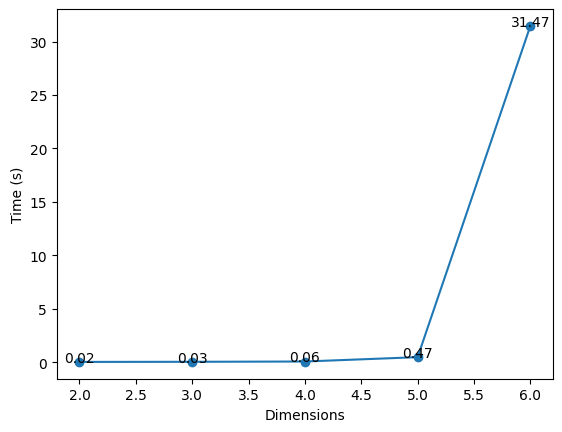

In [5]:
import util.perftest as perftest

with db.connect(DBNAME) as con:
    class ColumnPerfTest(perftest.PerfTest):
        def name(self):
            return "column_based"


        def setup_run(self, dimensions):
            # See the note above.
            generate_db_for_dimensions(con, dimensions - 1)

        def run(self, dimensions):
            query = generate_query_for_dimensions(dimensions - 1)
            results = con.execute(query)

        def x_labels(self):
            return [3, 4, 5, 6,]

    cad_perftest = perftest.measure_performance(ColumnPerfTest())
    perftest.plot_df(cad_perftest, "Dimensions")

We again see some bad scaling, but this approach is a 2x speedup compared to the
row-based approach at least.

In the next notebook we'll discuss a third approach, where we stick to the
column-based coefficients, but write intermediary results to separate tables.